ML Assignment 3

In [6]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import BaseEstimator, TransformerMixin
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2hsv, rgb2gray
from skimage.filters import sobel_h, sobel_v
from scipy.ndimage import uniform_filter
from skimage.measure import regionprops, label
from skimage.morphology import closing, square

In [9]:
# ==========================================
# STEP 0: GETTING DATA
# ==========================================

script_dir = os.getcwd()
file_path = os.path.join(script_dir, 'normalized_array_train.npy')

data_x = np.load(file_path)
Y_raw = np.genfromtxt('train.csv', delimiter=',', skip_header=1, usecols=(1,), dtype=int)

X = data_x
Y = Y_raw.ravel()

# Verification of shape
print(f"X shape: {X.shape}") # Should be (50000, 3072)
print(f"y shape: {Y.shape}") # Should be (50000,)

X shape: (50000, 3072)
y shape: (50000,)


In [13]:
# ==========================================
# STEP 1: FIXED FEATURE TRANSFORMERS
# ==========================================
class HOGTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
        self.orientations = orientations
        self.pixels_per_cell = pixels_per_cell
        self.cells_per_block = cells_per_block

    def fit(self, X, y=None): return self

    def transform(self, X):
        def extract_hog(row):
            img = row.reshape(32, 32, 3)
            return hog(img, orientations=self.orientations, 
                       pixels_per_cell=self.pixels_per_cell,
                       cells_per_block=self.cells_per_block, 
                       transform_sqrt=True, 
                       channel_axis=-1)
        return np.array([extract_hog(row) for row in X])

class ColorHistogramTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, bins=32):
        self.bins = bins

    def fit(self, X, y=None): return self

    def transform(self, X):
        def extract_color_hist(row):
            img_hsv = rgb2hsv(row.reshape(32, 32, 3))
            h_hist, _ = np.histogram(img_hsv[:,:,0], bins=self.bins, range=(0, 1))
            s_hist, _ = np.histogram(img_hsv[:,:,1], bins=self.bins, range=(0, 1))
            v_hist, _ = np.histogram(img_hsv[:,:,2], bins=self.bins, range=(0, 1))
            hist = np.concatenate([h_hist, s_hist, v_hist])
            return hist / (np.sum(hist) + 1e-7)
        return np.array([extract_color_hist(row) for row in X])

class LBPTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, radius=1, n_points=8):
        self.radius = radius
        self.n_points = n_points

    def fit(self, X, y=None): return self

    def transform(self, X):
        def extract_lbp(row):
            gray_img = rgb2gray(row.reshape(32, 32, 3))
            gray_uint8 = (gray_img * 255).astype(np.uint8)
            lbp = local_binary_pattern(gray_uint8, self.n_points, self.radius, method='uniform')
            n_bins = self.n_points + 2
            hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
            return hist / (np.sum(hist) + 1e-7)
        return np.array([extract_lbp(row) for row in X])

class ShapeTransformer(BaseEstimator, TransformerMixin):
    """Cats are more compact/circular, dogs are more elongated"""
    def fit(self, X, y=None): return self
    
    def transform(self, X):
        features = []
        for row in X:
            img = row.reshape(32, 32, 3)
            gray = rgb2gray(img)
            
            # Threshold to get rough silhouette
            binary = gray > gray.mean()
            binary = closing(binary, square(3))
            
            # Get largest connected region
            labeled = label(binary)
            if labeled.max() == 0:
                features.append([0.5, 0.5, 0.5])
                continue
                
            props = regionprops(labeled)[0]
            
            # Key shape descriptors
            eccentricity = props.eccentricity  # 0=circle, 1=line (dogs more elongated)
            solidity = props.solidity          # Convexness (cats more compact)
            extent = props.extent              # Bbox fill ratio
            
            features.append([eccentricity, solidity, extent])
            
        return np.array(features)

class EnhancedTextureTransformer(BaseEstimator, TransformerMixin):
    """Cats have finer, more uniform fur texture"""
    def fit(self, X, y=None): return self
    
    def transform(self, X):
        features = []
        for row in X:
            gray = rgb2gray(row.reshape(32, 32, 3))
            
            # Multi-scale variance (fur texture at different scales)
            var_3x3 = uniform_filter(gray**2, 3) - uniform_filter(gray, 3)**2
            var_5x5 = uniform_filter(gray**2, 5) - uniform_filter(gray, 5)**2
            var_7x7 = uniform_filter(gray**2, 7) - uniform_filter(gray, 7)**2
            
            # Edge density (whiskers, facial features)
            v_edge = np.abs(sobel_v(gray))
            h_edge = np.abs(sobel_h(gray))
            
            # Directional texture
            direction_ratio = v_edge.sum() / (h_edge.sum() + 1e-7)
            edge_density = (v_edge + h_edge).mean()
            
            features.append([
                var_3x3.mean(),
                var_5x5.mean(), 
                var_7x7.mean(),
                direction_ratio,
                edge_density
            ])
            
        return np.array(features)

print('transformers loaded')

transformers loaded


In [14]:
# ==========================================
# STEP 2: DATA SETUP & AUGMENTATION
# ==========================================

def augment_data(X, y):
    X_h_flipped = np.array([np.fliplr(row.reshape(32, 32, 3)).flatten() for row in X])
    return np.vstack([X, X_h_flipped]), np.concatenate([y, y])

X_train_raw, X_val, y_train_raw, y_val = train_test_split(
    X, Y, train_size=7000, stratify=Y, random_state=42
)
print('validation data split')

validation data split


In [15]:
# ==========================================
# STEP 3: FIXED PIPELINE 
# ==========================================

best_pipeline = Pipeline([
    ('features', FeatureUnion([
    ('hog', HOGTransformer()),
    ('color', ColorHistogramTransformer()),
    ('lbp', LBPTransformer()),
    ('edge', ShapeTransformer()), 
    ('text', EnhancedTextureTransformer())
])),
    ('scaler', StandardScaler(with_mean=False)),
    ('pca', PCA(n_components=0.99, whiten=False, random_state=42)),
    ('ensemble', BaggingClassifier(
        estimator=SVC(kernel='rbf', C=100, gamma='scale'),
        n_estimators=75, 
        max_samples=0.7,
        max_features=0.75, 
        n_jobs=-1,
        random_state=42
    ))
])
print('Pipeline set')

Pipeline set


validation sample ready
Fitting validation model...


C:\Users\Tiger\AppData\Local\Temp\ipykernel_39732\355448768.py:67: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  binary = closing(binary, square(3))


Generating Confusion Matrix on Validation Set...


C:\Users\Tiger\AppData\Local\Temp\ipykernel_39732\355448768.py:67: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  binary = closing(binary, square(3))


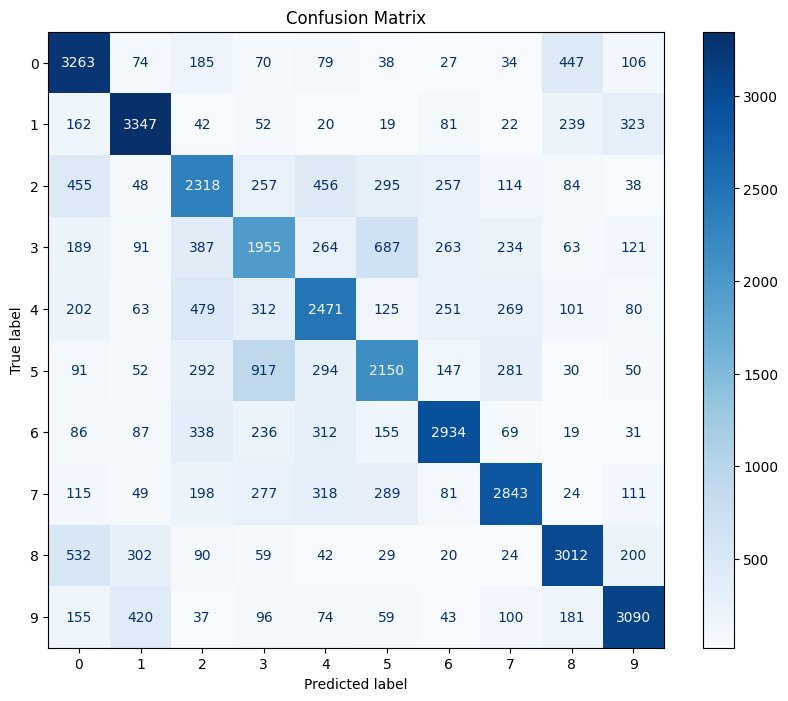

showing classification report
              precision    recall  f1-score   support

           0       0.62      0.75      0.68      4323
           1       0.74      0.78      0.76      4307
           2       0.53      0.54      0.53      4322
           3       0.46      0.46      0.46      4254
           4       0.57      0.57      0.57      4353
           5       0.56      0.50      0.53      4304
           6       0.71      0.69      0.70      4267
           7       0.71      0.66      0.69      4305
           8       0.72      0.70      0.71      4310
           9       0.74      0.73      0.74      4255

    accuracy                           0.64     43000
   macro avg       0.64      0.64      0.64     43000
weighted avg       0.64      0.64      0.64     43000



In [16]:
# ==========================================
# STEP 4: ERROR ANALYSIS (CONFUSION MATRIX)
# ==========================================

X_train_aug, y_train_aug = augment_data(X_train_raw, y_train_raw)
print('validation sample ready')

print("Fitting validation model...")
best_pipeline.fit(X_train_aug, y_train_aug)

print("Generating Confusion Matrix on Validation Set...")
y_val_pred = best_pipeline.predict(X_val)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

from sklearn.metrics import classification_report
print('showing classification report')
print(classification_report(y_val, y_val_pred))

Note: Ignore the future warning as it is not affecting the training now

In [19]:
# ==========================================
# STEP 5: MODEL TRAINING
# ==========================================

print('fitting final model...(it takes close to 2 hours on my pc)')
X_final_augmented,y_final_augmented = augment_data(X,Y)

best_final_model = best_pipeline
best_final_model.fit(X_final_augmented,y_final_augmented)

data_x = np.loadtxt('processed_data_Test.csv', delimiter=',')
Y_raw = np.genfromtxt('test.csv', delimiter=',', skip_header=1, usecols=(1,), dtype=int)

X_test = data_x
Y_test = Y_raw.ravel()

print('checking the format of the test case')
print(f"X shape: {X_test.shape}")
print(f"y shape: {Y_test.shape}") 

predictions = best_final_model.predict(X_test)
print('prediction done')

fitting final model...(it takes close to 2 hours on my pc)


C:\Users\Tiger\AppData\Local\Temp\ipykernel_39732\355448768.py:67: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  binary = closing(binary, square(3))


checking the format of the test case
X shape: (10000, 3072)
y shape: (10000,)


C:\Users\Tiger\AppData\Local\Temp\ipykernel_39732\355448768.py:67: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  binary = closing(binary, square(3))


prediction done


In [20]:
# ==========================================
# STEP 6: PREDICTION CSV OUTPUT
# ==========================================
import pandas as pd
df = pd.read_csv('test.csv')

if len(predictions) == len(df):
    df.iloc[:, 1] = predictions 
    df.to_csv('final_submission.csv', index=False)
    print("Submission file 'final_submission3.csv' created successfully!")
else:
    print(f"Error: Prediction length ({len(predictions)}) doesn't match CSV length ({len(df)})")
print(df.head())

Submission file 'final_submission3.csv' created successfully!
       im_name  label
0  d4f3098.jpg      6
1  d4f398e.jpg      9
2  d4f49f2.jpg      6
3  d4f503e.jpg      3
4  d4f8340.jpg      2


NOTE:
There was a Randomized search section in the code but it was until we fixed the parameters and it was taken out since performing it may result in inconsistent output. I will show part of it in the random forest model code we had when we tested different methods as below.

In [ ]:
param_dist = {
    'classifier__n_estimators': [100,200],
    'classifier__max_depth': [30, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt'],
    'classifier__criterion': ['gini', 'entropy'],
    'features__color__bins': [32], 
    
    'features__hog__pixels_per_cell': [(8, 8)],
    'features__hog__orientations': [9,12],
    
    'features__lbp__radius': [1, 2],
    'features__lbp__n_points': [8, 16],

    'pca__n_components': [0.95,0.98], 
    'pca__whiten': [False, True],
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=40,          
    cv=4,           # Increased to 4 for stable tuning!
    scoring='accuracy', 
    n_jobs=-1,          
    verbose=3,          
    random_state=42
)

random_search.fit(X_train_augmented, y_train_augmented)
best_final_model = random_search.best_estimator_
best_final_model.fit(X_final_augmented,y_final_augmented)